# Parameter-to-POD-coefficient surrogate for rotating-drum fields

## Purpose

This notebook constructs a non-intrusive reduced-order model for the
coarse-grained rotating-drum volume-fraction fields.

The workflow is:

1. load the validated training and test snapshot matrices;
2. construct a rank-six mean-centred POD basis using training data only;
3. calculate the six training POD coefficients;
4. learn the mapping from particle-size ratio to POD coefficients;
5. predict coefficients for the ten unseen test parameters;
6. reconstruct complete unseen volume-fraction fields;
7. separate POD projection error from surrogate prediction error;
8. compare interpolation and neural-network surrogate models.

The supplied test fields will not be used to fit or tune the surrogate models.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.interpolate import CubicSpline
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler


def find_project_root(start: Path) -> Path:
    """Locate the repository root from anywhere inside the project."""
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (
            (candidate / "data").exists()
            and (candidate / "notebooks").exists()
            and (candidate / "results").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the msc-rom-particle-systems project root."
    )


CURRENT_DIR = Path.cwd()
PROJECT_ROOT = find_project_root(CURRENT_DIR)

PROCESSED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "cg_phi_small_dataset.npz"
)

FIGURE_DIR = PROJECT_ROOT / "results" / "figures"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

if not PROCESSED_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Processed dataset was not found:\n{PROCESSED_DATA_PATH}"
    )

with np.load(
    PROCESSED_DATA_PATH,
    allow_pickle=False,
) as data:
    x_grid = data["x"]
    z_grid = data["z"]
    train_parameters = data["train_parameters"]
    test_parameters = data["test_parameters"]
    train_snapshot_matrix = data["train_snapshots"]
    test_snapshot_matrix = data["test_snapshots"]

print("Python executable:", sys.executable)
print("Processed dataset:", PROCESSED_DATA_PATH)
print("Training parameters:", train_parameters.shape)
print("Test parameters:", test_parameters.shape)
print("Training snapshots:", train_snapshot_matrix.shape)
print("Test snapshots:", test_snapshot_matrix.shape)

assert train_snapshot_matrix.shape == (10000, 100)
assert test_snapshot_matrix.shape == (10000, 10)
assert train_parameters.shape == (100,)
assert test_parameters.shape == (10,)
assert np.isfinite(train_snapshot_matrix).all()
assert np.isfinite(test_snapshot_matrix).all()
assert np.intersect1d(
    train_parameters,
    test_parameters,
).size == 0

print("\nProcessed dataset checks passed.")

Python executable: /Users/rallen/Documents/msc-rom-particle-systems/.venv/bin/python
Processed dataset: /Users/rallen/Documents/msc-rom-particle-systems/data/processed/cg_phi_small_dataset.npz
Training parameters: (100,)
Test parameters: (10,)
Training snapshots: (10000, 100)
Test snapshots: (10000, 10)

Processed dataset checks passed.


In [2]:
selected_rank = 6

# Store the mean training field separately.
mean_snapshot_vector = train_snapshot_matrix.mean(
    axis=1,
    keepdims=True,
)

# POD is applied to fluctuations around the training mean.
centred_train_snapshots = (
    train_snapshot_matrix
    - mean_snapshot_vector
)

(
    pod_modes_full,
    singular_values,
    right_singular_vectors,
) = np.linalg.svd(
    centred_train_snapshots,
    full_matrices=False,
)

pod_basis = pod_modes_full[
    :,
    :selected_rank,
]

# Each column contains the six coefficients for one training field.
train_coefficients = (
    pod_basis.T
    @ centred_train_snapshots
)

# Reconstruct the training fields to verify the basis.
reconstructed_train_snapshots = (
    mean_snapshot_vector
    + pod_basis
    @ train_coefficients
)

training_relative_errors = (
    np.linalg.norm(
        train_snapshot_matrix
        - reconstructed_train_snapshots,
        axis=0,
    )
    / np.linalg.norm(
        train_snapshot_matrix,
        axis=0,
    )
)

orthonormality_error = np.linalg.norm(
    pod_basis.T @ pod_basis
    - np.eye(selected_rank)
)

captured_energy = (
    np.sum(
        singular_values[:selected_rank] ** 2
    )
    / np.sum(
        singular_values**2
    )
)

print("Selected POD rank:", selected_rank)
print("POD basis shape:", pod_basis.shape)
print(
    "Training coefficient matrix shape:",
    train_coefficients.shape,
)
print(
    "Captured fluctuation energy:",
    f"{captured_energy:.8f}",
)
print(
    "Mean training reconstruction error:",
    f"{training_relative_errors.mean():.6e}",
)
print(
    "Maximum training reconstruction error:",
    f"{training_relative_errors.max():.6e}",
)
print(
    "Basis orthonormality error:",
    f"{orthonormality_error:.6e}",
)

assert pod_basis.shape == (
    10000,
    selected_rank,
)

assert train_coefficients.shape == (
    selected_rank,
    100,
)

assert orthonormality_error < 1e-10

print("\nRank-six POD model checks passed.")

Selected POD rank: 6
POD basis shape: (10000, 6)
Training coefficient matrix shape: (6, 100)
Captured fluctuation energy: 0.99902857
Mean training reconstruction error: 4.773766e-03
Maximum training reconstruction error: 9.081565e-03
Basis orthonormality error: 4.901291e-15

Rank-six POD model checks passed.


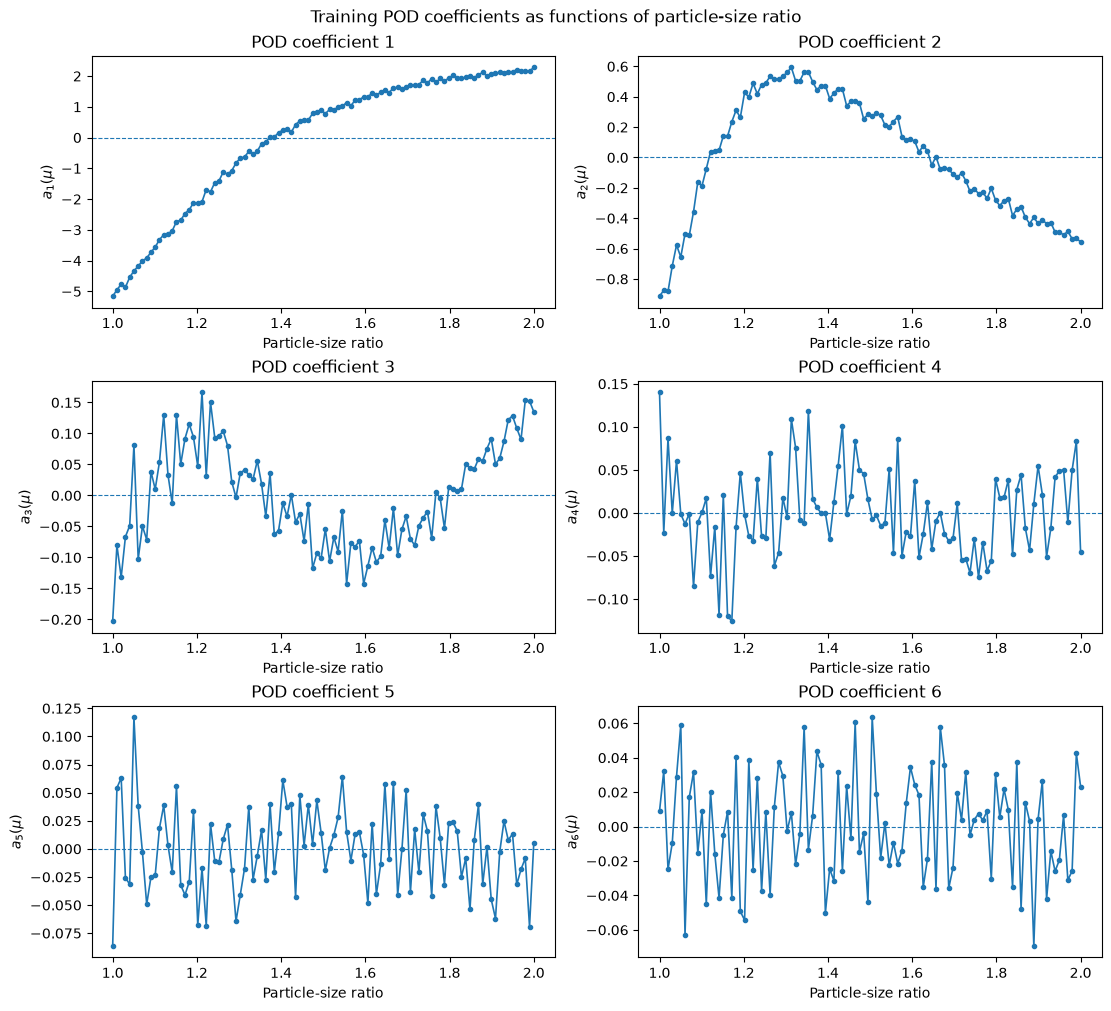

Saved figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_training_pod_coefficients.pdf

Saved coefficient table:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_training_pod_coefficients.csv


,size_ratio,coefficient_1,coefficient_2,coefficient_3,coefficient_4,coefficient_5,coefficient_6
0,1.000000,-5.159144,-0.914015,-0.202760,0.140123,-0.086441,0.008908
1,1.010101,-4.951658,-0.874207,-0.080440,-0.022815,0.054265,0.032188
2,1.020202,-4.766845,-0.882166,-0.132013,0.086633,0.063015,-0.024784
3,1.030303,-4.867480,-0.714269,-0.066599,-0.000281,-0.025711,-0.009537
4,1.040404,-4.540978,-0.576592,-0.048766,0.060884,-0.031498,0.029071


In [3]:
figure, axes = plt.subplots(
    3,
    2,
    figsize=(11, 10),
    constrained_layout=True,
)

axes = axes.ravel()

for mode_index, axis in enumerate(
    axes
):
    axis.plot(
        train_parameters,
        train_coefficients[
            mode_index,
            :,
        ],
        marker="o",
        markersize=3,
        linewidth=1.2,
    )

    axis.axhline(
        0.0,
        linewidth=0.8,
        linestyle="--",
    )

    axis.set_xlabel(
        "Particle-size ratio"
    )

    axis.set_ylabel(
        rf"$a_{mode_index + 1}(\mu)$"
    )

    axis.set_title(
        f"POD coefficient {mode_index + 1}"
    )

figure.suptitle(
    "Training POD coefficients as functions of particle-size ratio"
)

coefficient_figure_path = (
    FIGURE_DIR
    / "cg_phi_training_pod_coefficients.pdf"
)

figure.savefig(
    coefficient_figure_path,
    bbox_inches="tight",
)

plt.show()

print("Saved figure:")
print(coefficient_figure_path)


coefficient_table = pd.DataFrame(
    {
        "size_ratio": train_parameters,
        **{
            f"coefficient_{mode_index + 1}":
            train_coefficients[
                mode_index,
                :,
            ]
            for mode_index in range(
                selected_rank
            )
        },
    }
)

coefficient_table_path = (
    TABLE_DIR
    / "cg_phi_training_pod_coefficients.csv"
)

coefficient_table.to_csv(
    coefficient_table_path,
    index=False,
)

print("\nSaved coefficient table:")
print(coefficient_table_path)

display(
    coefficient_table.head()
)

In [4]:
centred_test_snapshots = (
    test_snapshot_matrix
    - mean_snapshot_vector
)

# Orthogonal projection gives the best coefficients available
# within the fixed rank-six POD space.
projected_test_coefficients = (
    pod_basis.T
    @ centred_test_snapshots
)

projected_test_snapshots = (
    mean_snapshot_vector
    + pod_basis
    @ projected_test_coefficients
)

projection_relative_errors = (
    np.linalg.norm(
        test_snapshot_matrix
        - projected_test_snapshots,
        axis=0,
    )
    / np.linalg.norm(
        test_snapshot_matrix,
        axis=0,
    )
)

print("Rank-six projection benchmark")
print("-----------------------------")

print(
    "Mean projection error:",
    f"{projection_relative_errors.mean():.6e}",
)

print(
    "Maximum projection error:",
    f"{projection_relative_errors.max():.6e}",
)

print(
    "Worst test parameter:",
    f"{test_parameters[np.argmax(projection_relative_errors)]:.6f}",
)

print(
    "\nProjected test coefficient shape:",
    projected_test_coefficients.shape,
)

Rank-six projection benchmark
-----------------------------
Mean projection error: 5.034892e-03
Maximum projection error: 7.215174e-03
Worst test parameter: 1.125000

Projected test coefficient shape: (6, 10)


In [5]:
linear_predicted_coefficients = np.vstack(
    [
        np.interp(
            test_parameters,
            train_parameters,
            train_coefficients[mode_index, :],
        )
        for mode_index in range(selected_rank)
    ]
)

linear_predicted_snapshots = (
    mean_snapshot_vector
    + pod_basis
    @ linear_predicted_coefficients
)

linear_relative_errors = (
    np.linalg.norm(
        test_snapshot_matrix
        - linear_predicted_snapshots,
        axis=0,
    )
    / np.linalg.norm(
        test_snapshot_matrix,
        axis=0,
    )
)

coefficient_rmse = np.sqrt(
    np.mean(
        (
            linear_predicted_coefficients
            - projected_test_coefficients
        ) ** 2,
        axis=1,
    )
)

training_coefficient_scales = np.std(
    train_coefficients,
    axis=1,
)

normalised_coefficient_rmse = (
    coefficient_rmse
    / np.maximum(
        training_coefficient_scales,
        np.finfo(float).tiny,
    )
)

surrogate_excess_errors = (
    linear_relative_errors
    - projection_relative_errors
)

print("Linear-interpolation surrogate")
print("------------------------------")

print(
    "Mean surrogate field error:",
    f"{linear_relative_errors.mean():.6e}",
)

print(
    "Maximum surrogate field error:",
    f"{linear_relative_errors.max():.6e}",
)

print(
    "Mean excess above projection error:",
    f"{surrogate_excess_errors.mean():.6e}",
)

print(
    "Maximum excess above projection error:",
    f"{surrogate_excess_errors.max():.6e}",
)

print("\nCoefficient errors by POD mode:")

for mode_index in range(selected_rank):
    print(
        f"  Mode {mode_index + 1}: "
        f"RMSE = {coefficient_rmse[mode_index]:.6e}, "
        f"normalised RMSE = "
        f"{normalised_coefficient_rmse[mode_index]:.6e}"
    )

linear_results = pd.DataFrame(
    {
        "size_ratio": test_parameters,
        "projection_error": projection_relative_errors,
        "linear_surrogate_error": linear_relative_errors,
        "surrogate_excess_error": surrogate_excess_errors,
    }
)

linear_results_path = (
    TABLE_DIR
    / "cg_phi_linear_surrogate_test_errors.csv"
)

linear_results.to_csv(
    linear_results_path,
    index=False,
)

print("\nSaved results table:")
print(linear_results_path)

display(linear_results)

Linear-interpolation surrogate
------------------------------
Mean surrogate field error: 9.821346e-03
Maximum surrogate field error: 1.906144e-02
Mean excess above projection error: 4.786454e-03
Maximum excess above projection error: 1.258261e-02

Coefficient errors by POD mode:
  Mode 1: RMSE = 6.033924e-02, normalised RMSE = 2.796615e-02
  Mode 2: RMSE = 6.787198e-02, normalised RMSE = 1.709234e-01
  Mode 3: RMSE = 5.412698e-02, normalised RMSE = 6.717917e-01
  Mode 4: RMSE = 4.543822e-02, normalised RMSE = 9.022457e-01
  Mode 5: RMSE = 3.013745e-02, normalised RMSE = 8.281560e-01
  Mode 6: RMSE = 3.541863e-02, normalised RMSE = 1.158129e+00

Saved results table:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_linear_surrogate_test_errors.csv


,size_ratio,projection_error,linear_surrogate_error,surrogate_excess_error
0,1.0625,0.006479,0.019061,0.012583
1,1.1250,0.007215,0.011532,0.004317
2,1.2500,0.005612,0.009023,0.003412
3,1.3125,0.004812,0.010511,0.005700
4,1.3750,0.003677,0.010502,0.006824
5,1.5000,0.004636,0.012076,0.007440
6,1.5625,0.004612,0.007741,0.003129
7,1.6250,0.004527,0.006459,0.001931
8,1.7500,0.004430,0.005266,0.000836
9,1.8750,0.004349,0.006042,0.001693


In [6]:
from scipy.interpolate import PchipInterpolator


def predict_pod_coefficients(
    method: str,
    fitting_parameters: np.ndarray,
    fitting_coefficients: np.ndarray,
    query_parameters: np.ndarray,
) -> np.ndarray:
    """Fit one interpolant per POD mode and predict query coefficients."""
    sorting_indices = np.argsort(
        fitting_parameters
    )

    sorted_parameters = fitting_parameters[
        sorting_indices
    ]

    sorted_coefficients = fitting_coefficients[
        :,
        sorting_indices,
    ]

    predictions = []

    for mode_index in range(
        sorted_coefficients.shape[0]
    ):
        coefficient_values = sorted_coefficients[
            mode_index,
            :,
        ]

        if method == "linear":
            predicted_values = np.interp(
                query_parameters,
                sorted_parameters,
                coefficient_values,
            )

        elif method == "pchip":
            interpolator = PchipInterpolator(
                sorted_parameters,
                coefficient_values,
                extrapolate=False,
            )

            predicted_values = interpolator(
                query_parameters
            )

        elif method == "natural_cubic":
            interpolator = CubicSpline(
                sorted_parameters,
                coefficient_values,
                bc_type="natural",
                extrapolate=False,
            )

            predicted_values = interpolator(
                query_parameters
            )

        else:
            raise ValueError(
                f"Unknown surrogate method: {method}"
            )

        predictions.append(
            predicted_values
        )

    predicted_coefficients = np.vstack(
        predictions
    )

    if not np.isfinite(
        predicted_coefficients
    ).all():
        raise ValueError(
            f"{method} produced non-finite predictions."
        )

    return predicted_coefficients


candidate_methods = [
    "linear",
    "pchip",
    "natural_cubic",
]

number_of_folds = 5

# The endpoints remain in every fitting set, ensuring that
# validation predictions are interpolation rather than extrapolation.
internal_indices = np.arange(
    1,
    train_parameters.size - 1,
)

validation_folds = [
    internal_indices[
        np.arange(
            internal_indices.size
        ) % number_of_folds
        == fold_index
    ]
    for fold_index in range(
        number_of_folds
    )
]

print("Candidate methods:")
for method in candidate_methods:
    print(" ", method)

print("\nValidation fold sizes:")
for fold_index, validation_indices in enumerate(
    validation_folds,
    start=1,
):
    print(
        f"  Fold {fold_index}: "
        f"{validation_indices.size} cases"
    )

Candidate methods:
  linear
  pchip
  natural_cubic

Validation fold sizes:
  Fold 1: 20 cases
  Fold 2: 20 cases
  Fold 3: 20 cases
  Fold 4: 19 cases
  Fold 5: 19 cases


In [7]:
cross_validation_records = []
cross_validation_predictions = {}
cross_validation_field_errors = {}

all_training_indices = np.arange(
    train_parameters.size
)

for method in candidate_methods:
    predicted_coefficients = np.full(
        train_coefficients.shape,
        np.nan,
        dtype=float,
    )

    validation_mask = np.zeros(
        train_parameters.size,
        dtype=bool,
    )

    for validation_indices in validation_folds:
        fitting_indices = np.setdiff1d(
            all_training_indices,
            validation_indices,
        )

        fold_predictions = predict_pod_coefficients(
            method=method,
            fitting_parameters=train_parameters[
                fitting_indices
            ],
            fitting_coefficients=train_coefficients[
                :,
                fitting_indices,
            ],
            query_parameters=train_parameters[
                validation_indices
            ],
        )

        predicted_coefficients[
            :,
            validation_indices,
        ] = fold_predictions

        validation_mask[
            validation_indices
        ] = True

    true_validation_coefficients = train_coefficients[
        :,
        validation_mask,
    ]

    predicted_validation_coefficients = (
        predicted_coefficients[
            :,
            validation_mask,
        ]
    )

    validation_snapshots = train_snapshot_matrix[
        :,
        validation_mask,
    ]

    predicted_validation_snapshots = (
        mean_snapshot_vector
        + pod_basis
        @ predicted_validation_coefficients
    )

    field_errors = (
        np.linalg.norm(
            validation_snapshots
            - predicted_validation_snapshots,
            axis=0,
        )
        / np.linalg.norm(
            validation_snapshots,
            axis=0,
        )
    )

    coefficient_rmse_by_mode = np.sqrt(
        np.mean(
            (
                true_validation_coefficients
                - predicted_validation_coefficients
            ) ** 2,
            axis=1,
        )
    )

    coefficient_scale_by_mode = np.std(
        true_validation_coefficients,
        axis=1,
    )

    normalised_rmse_by_mode = (
        coefficient_rmse_by_mode
        / np.maximum(
            coefficient_scale_by_mode,
            np.finfo(float).tiny,
        )
    )

    cross_validation_predictions[
        method
    ] = predicted_coefficients

    cross_validation_field_errors[
        method
    ] = field_errors

    cross_validation_records.append(
        {
            "method": method,
            "mean_field_error": field_errors.mean(),
            "maximum_field_error": field_errors.max(),
            "median_field_error": np.median(
                field_errors
            ),
            "mean_coefficient_nrmse": (
                normalised_rmse_by_mode.mean()
            ),
            "maximum_coefficient_nrmse": (
                normalised_rmse_by_mode.max()
            ),
        }
    )

cross_validation_summary = pd.DataFrame(
    cross_validation_records
).sort_values(
    "mean_field_error"
).reset_index(
    drop=True
)

print(
    "Training-only surrogate cross-validation results:"
)

display(
    cross_validation_summary
)

best_method = str(
    cross_validation_summary.iloc[0][
        "method"
    ]
)

print(
    "\nSelected method:",
    best_method,
)

Training-only surrogate cross-validation results:


,method,mean_field_error,maximum_field_error,median_field_error,mean_coefficient_nrmse,maximum_coefficient_nrmse
0,linear,0.010391,0.023045,0.009673,0.757823,1.379382
1,pchip,0.010799,0.025769,0.010129,0.777747,1.426593
2,natural_cubic,0.012515,0.030093,0.012344,0.944047,1.716736



Selected method: linear


Selected surrogate: linear
Mean test field error: 9.821346e-03
Maximum test field error: 1.906144e-02
Mean excess above projection floor: 4.786454e-03
Maximum excess above projection floor: 1.258261e-02

Coefficient test errors:
  Mode 1: RMSE = 6.033924e-02, normalised RMSE = 2.796615e-02
  Mode 2: RMSE = 6.787198e-02, normalised RMSE = 1.709234e-01
  Mode 3: RMSE = 5.412698e-02, normalised RMSE = 6.717917e-01
  Mode 4: RMSE = 4.543822e-02, normalised RMSE = 9.022457e-01
  Mode 5: RMSE = 3.013745e-02, normalised RMSE = 8.281560e-01
  Mode 6: RMSE = 3.541863e-02, normalised RMSE = 1.158129e+00


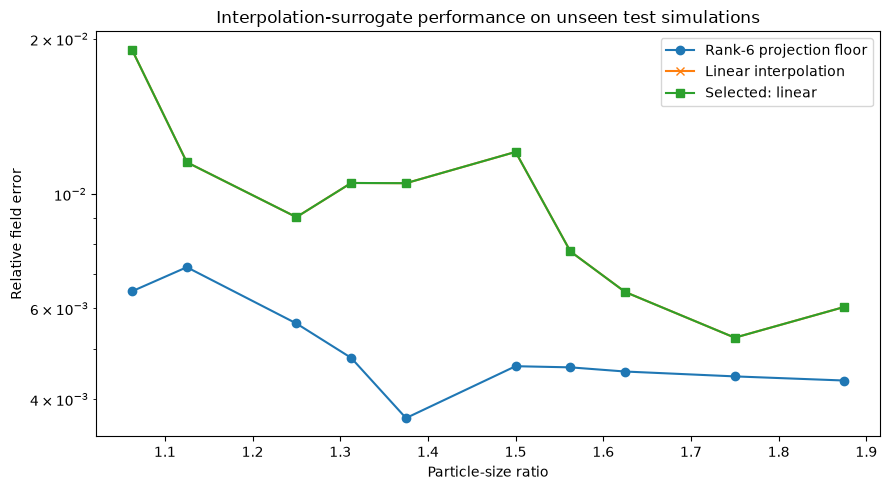


Saved comparison table:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_interpolation_surrogate_comparison.csv

Saved comparison figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_interpolation_surrogate_comparison.pdf


,size_ratio,projection_error,linear_error,linear_excess_error
0,1.0625,0.006479,0.019061,0.012583
1,1.1250,0.007215,0.011532,0.004317
2,1.2500,0.005612,0.009023,0.003412
3,1.3125,0.004812,0.010511,0.005700
4,1.3750,0.003677,0.010502,0.006824
5,1.5000,0.004636,0.012076,0.007440
6,1.5625,0.004612,0.007741,0.003129
7,1.6250,0.004527,0.006459,0.001931
8,1.7500,0.004430,0.005266,0.000836
9,1.8750,0.004349,0.006042,0.001693


In [8]:
selected_test_coefficients = predict_pod_coefficients(
    method=best_method,
    fitting_parameters=train_parameters,
    fitting_coefficients=train_coefficients,
    query_parameters=test_parameters,
)

selected_test_snapshots = (
    mean_snapshot_vector
    + pod_basis
    @ selected_test_coefficients
)

selected_test_errors = (
    np.linalg.norm(
        test_snapshot_matrix
        - selected_test_snapshots,
        axis=0,
    )
    / np.linalg.norm(
        test_snapshot_matrix,
        axis=0,
    )
)

selected_excess_errors = (
    selected_test_errors
    - projection_relative_errors
)

selected_coefficient_rmse = np.sqrt(
    np.mean(
        (
            selected_test_coefficients
            - projected_test_coefficients
        ) ** 2,
        axis=1,
    )
)

selected_coefficient_nrmse = (
    selected_coefficient_rmse
    / np.maximum(
        np.std(
            train_coefficients,
            axis=1,
        ),
        np.finfo(float).tiny,
    )
)

print(
    f"Selected surrogate: {best_method}"
)

print(
    "Mean test field error:",
    f"{selected_test_errors.mean():.6e}",
)

print(
    "Maximum test field error:",
    f"{selected_test_errors.max():.6e}",
)

print(
    "Mean excess above projection floor:",
    f"{selected_excess_errors.mean():.6e}",
)

print(
    "Maximum excess above projection floor:",
    f"{selected_excess_errors.max():.6e}",
)

print("\nCoefficient test errors:")

for mode_index in range(
    selected_rank
):
    print(
        f"  Mode {mode_index + 1}: "
        f"RMSE = "
        f"{selected_coefficient_rmse[mode_index]:.6e}, "
        f"normalised RMSE = "
        f"{selected_coefficient_nrmse[mode_index]:.6e}"
    )


surrogate_comparison_table = pd.DataFrame(
    {
        "size_ratio": test_parameters,
        "projection_error": projection_relative_errors,
        "linear_error": linear_relative_errors,
        f"{best_method}_error": selected_test_errors,
        f"{best_method}_excess_error": (
            selected_excess_errors
        ),
    }
)

comparison_table_path = (
    TABLE_DIR
    / "cg_phi_interpolation_surrogate_comparison.csv"
)

surrogate_comparison_table.to_csv(
    comparison_table_path,
    index=False,
)

plt.figure(
    figsize=(9, 5)
)

plt.semilogy(
    test_parameters,
    projection_relative_errors,
    marker="o",
    label="Rank-6 projection floor",
)

plt.semilogy(
    test_parameters,
    linear_relative_errors,
    marker="x",
    label="Linear interpolation",
)

plt.semilogy(
    test_parameters,
    selected_test_errors,
    marker="s",
    label=f"Selected: {best_method}",
)

plt.xlabel(
    "Particle-size ratio"
)

plt.ylabel(
    "Relative field error"
)

plt.title(
    "Interpolation-surrogate performance "
    "on unseen test simulations"
)

plt.legend()
plt.tight_layout()

comparison_figure_path = (
    FIGURE_DIR
    / "cg_phi_interpolation_surrogate_comparison.pdf"
)

plt.savefig(
    comparison_figure_path,
    bbox_inches="tight",
)

plt.show()

print("\nSaved comparison table:")
print(comparison_table_path)

print("\nSaved comparison figure:")
print(comparison_figure_path)

display(
    surrogate_comparison_table
)

In [9]:
from sklearn.exceptions import ConvergenceWarning
from sklearn.neural_network import MLPRegressor

warnings.filterwarnings(
    "ignore",
    category=ConvergenceWarning,
)


def fit_predict_neural_network(
    fitting_parameters: np.ndarray,
    fitting_coefficients: np.ndarray,
    query_parameters: np.ndarray,
    hidden_layer_sizes: tuple[int, ...],
    alpha: float,
    random_state: int = 42,
) -> np.ndarray:
    """
    Fit a standardised neural network and predict POD coefficients.

    Scaling is fitted using only the supplied fitting data, preventing
    information leakage during cross-validation.
    """
    input_scaler = StandardScaler()
    output_scaler = StandardScaler()

    fitting_inputs = input_scaler.fit_transform(
        fitting_parameters.reshape(-1, 1)
    )

    query_inputs = input_scaler.transform(
        query_parameters.reshape(-1, 1)
    )

    fitting_outputs = output_scaler.fit_transform(
        fitting_coefficients.T
    )

    model = MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="tanh",
        solver="lbfgs",
        alpha=alpha,
        max_iter=5000,
        random_state=random_state,
    )

    model.fit(
        fitting_inputs,
        fitting_outputs,
    )

    scaled_predictions = model.predict(
        query_inputs
    )

    predicted_coefficients = (
        output_scaler.inverse_transform(
            scaled_predictions
        ).T
    )

    if not np.isfinite(
        predicted_coefficients
    ).all():
        raise ValueError(
            "The neural network produced non-finite predictions."
        )

    return predicted_coefficients


neural_network_candidates = [
    {
        "name": "mlp_8_alpha_1e-3",
        "hidden_layer_sizes": (8,),
        "alpha": 1e-3,
    },
    {
        "name": "mlp_16_alpha_1e-3",
        "hidden_layer_sizes": (16,),
        "alpha": 1e-3,
    },
    {
        "name": "mlp_16_8_alpha_1e-3",
        "hidden_layer_sizes": (16, 8),
        "alpha": 1e-3,
    },
    {
        "name": "mlp_16_alpha_1e-2",
        "hidden_layer_sizes": (16,),
        "alpha": 1e-2,
    },
    {
        "name": "mlp_16_alpha_1e-1",
        "hidden_layer_sizes": (16,),
        "alpha": 1e-1,
    },
]

print("Neural-network candidates:")

for candidate in neural_network_candidates:
    print(
        f"  {candidate['name']}: "
        f"layers={candidate['hidden_layer_sizes']}, "
        f"alpha={candidate['alpha']}"
    )

Neural-network candidates:
  mlp_8_alpha_1e-3: layers=(8,), alpha=0.001
  mlp_16_alpha_1e-3: layers=(16,), alpha=0.001
  mlp_16_8_alpha_1e-3: layers=(16, 8), alpha=0.001
  mlp_16_alpha_1e-2: layers=(16,), alpha=0.01
  mlp_16_alpha_1e-1: layers=(16,), alpha=0.1


In [10]:
neural_cross_validation_records = []

all_training_indices = np.arange(
    train_parameters.size
)

for candidate in neural_network_candidates:
    all_validation_errors = []
    all_true_coefficients = []
    all_predicted_coefficients = []

    for fold_number, validation_indices in enumerate(
        validation_folds,
        start=1,
    ):
        fitting_indices = np.setdiff1d(
            all_training_indices,
            validation_indices,
        )

        fold_predictions = fit_predict_neural_network(
            fitting_parameters=train_parameters[
                fitting_indices
            ],
            fitting_coefficients=train_coefficients[
                :,
                fitting_indices,
            ],
            query_parameters=train_parameters[
                validation_indices
            ],
            hidden_layer_sizes=candidate[
                "hidden_layer_sizes"
            ],
            alpha=candidate["alpha"],
            random_state=100 + fold_number,
        )

        fold_predicted_snapshots = (
            mean_snapshot_vector
            + pod_basis
            @ fold_predictions
        )

        fold_true_snapshots = (
            train_snapshot_matrix[
                :,
                validation_indices,
            ]
        )

        fold_field_errors = (
            np.linalg.norm(
                fold_true_snapshots
                - fold_predicted_snapshots,
                axis=0,
            )
            / np.linalg.norm(
                fold_true_snapshots,
                axis=0,
            )
        )

        all_validation_errors.append(
            fold_field_errors
        )

        all_true_coefficients.append(
            train_coefficients[
                :,
                validation_indices,
            ]
        )

        all_predicted_coefficients.append(
            fold_predictions
        )

    validation_errors = np.concatenate(
        all_validation_errors
    )

    true_coefficients = np.column_stack(
        all_true_coefficients
    )

    predicted_coefficients = np.column_stack(
        all_predicted_coefficients
    )

    coefficient_rmse = np.sqrt(
        np.mean(
            (
                true_coefficients
                - predicted_coefficients
            ) ** 2,
            axis=1,
        )
    )

    coefficient_nrmse = (
        coefficient_rmse
        / np.maximum(
            np.std(
                true_coefficients,
                axis=1,
            ),
            np.finfo(float).tiny,
        )
    )

    neural_cross_validation_records.append(
        {
            "model": candidate["name"],
            "hidden_layers": str(
                candidate["hidden_layer_sizes"]
            ),
            "alpha": candidate["alpha"],
            "mean_field_error": (
                validation_errors.mean()
            ),
            "median_field_error": np.median(
                validation_errors
            ),
            "maximum_field_error": (
                validation_errors.max()
            ),
            "mean_coefficient_nrmse": (
                coefficient_nrmse.mean()
            ),
            "maximum_coefficient_nrmse": (
                coefficient_nrmse.max()
            ),
        }
    )

neural_cross_validation_summary = pd.DataFrame(
    neural_cross_validation_records
).sort_values(
    "mean_field_error"
).reset_index(
    drop=True
)

print(
    "Neural-network training-only "
    "cross-validation results:"
)

display(
    neural_cross_validation_summary
)

best_neural_model_name = str(
    neural_cross_validation_summary.iloc[0][
        "model"
    ]
)

best_neural_candidate = next(
    candidate
    for candidate in neural_network_candidates
    if candidate["name"]
    == best_neural_model_name
)

print(
    "\nSelected neural-network candidate:",
    best_neural_model_name,
)

Neural-network training-only cross-validation results:


,model,hidden_layers,alpha,mean_field_error,median_field_error,maximum_field_error,mean_coefficient_nrmse,maximum_coefficient_nrmse
0,mlp_16_alpha_1e-1,"(16,)",0.100,0.009047,0.008335,0.020050,0.607698,1.042773
1,mlp_16_alpha_1e-2,"(16,)",0.010,0.009303,0.008505,0.019850,0.638368,1.099006
2,mlp_8_alpha_1e-3,"(8,)",0.001,0.009752,0.008591,0.023711,0.634226,1.083177
3,mlp_16_alpha_1e-3,"(16,)",0.001,0.009776,0.008996,0.020916,0.655650,1.125232
4,mlp_16_8_alpha_1e-3,"(16, 8)",0.001,0.013307,0.011933,0.050361,0.694865,1.190250



Selected neural-network candidate: mlp_16_alpha_1e-1


Selected neural network: mlp_16_alpha_1e-1
Mean neural-network field error: 8.392985e-03
Maximum neural-network field error: 1.304164e-02
Mean excess above projection floor: 3.358093e-03
Maximum excess above projection floor: 6.562815e-03

Coefficient errors by POD mode:
  Mode 1: RMSE = 5.702664e-02, normalised RMSE = 2.643083e-02
  Mode 2: RMSE = 4.982970e-02, normalised RMSE = 1.254872e-01
  Mode 3: RMSE = 3.545711e-02, normalised RMSE = 4.400725e-01
  Mode 4: RMSE = 3.722409e-02, normalised RMSE = 7.391415e-01
  Mode 5: RMSE = 2.393064e-02, normalised RMSE = 6.575973e-01
  Mode 6: RMSE = 2.378192e-02, normalised RMSE = 7.776283e-01


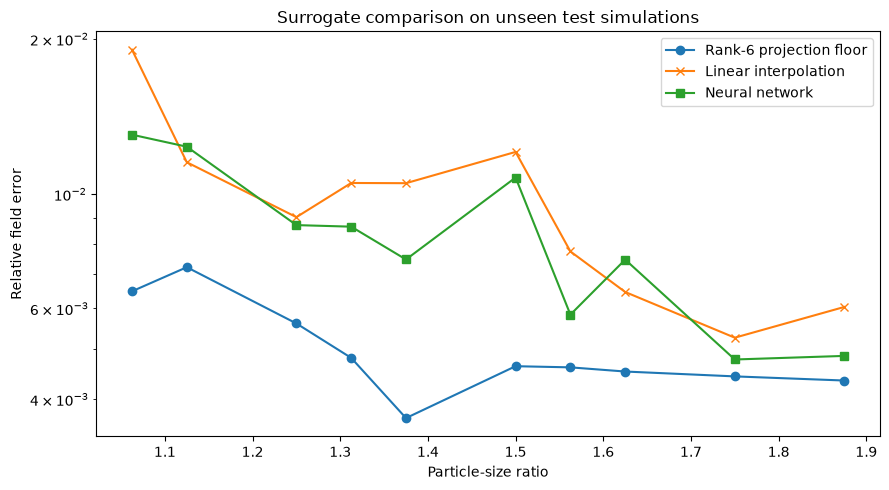


Saved results table:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_neural_surrogate_comparison.csv

Saved comparison figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_neural_surrogate_comparison.pdf


,size_ratio,projection_error,linear_error,neural_network_error,neural_network_excess_error
0,1.0625,0.006479,0.019061,0.013042,0.006563
1,1.1250,0.007215,0.011532,0.012361,0.005145
2,1.2500,0.005612,0.009023,0.008708,0.003096
3,1.3125,0.004812,0.010511,0.008648,0.003836
4,1.3750,0.003677,0.010502,0.007468,0.003791
5,1.5000,0.004636,0.012076,0.010770,0.006134
6,1.5625,0.004612,0.007741,0.005838,0.001225
7,1.6250,0.004527,0.006459,0.007464,0.002937
8,1.7500,0.004430,0.005266,0.004777,0.000347
9,1.8750,0.004349,0.006042,0.004855,0.000506


In [11]:
neural_test_coefficients = (
    fit_predict_neural_network(
        fitting_parameters=train_parameters,
        fitting_coefficients=train_coefficients,
        query_parameters=test_parameters,
        hidden_layer_sizes=best_neural_candidate[
            "hidden_layer_sizes"
        ],
        alpha=best_neural_candidate["alpha"],
        random_state=42,
    )
)

neural_test_snapshots = (
    mean_snapshot_vector
    + pod_basis
    @ neural_test_coefficients
)

neural_test_errors = (
    np.linalg.norm(
        test_snapshot_matrix
        - neural_test_snapshots,
        axis=0,
    )
    / np.linalg.norm(
        test_snapshot_matrix,
        axis=0,
    )
)

neural_excess_errors = (
    neural_test_errors
    - projection_relative_errors
)

neural_coefficient_rmse = np.sqrt(
    np.mean(
        (
            neural_test_coefficients
            - projected_test_coefficients
        ) ** 2,
        axis=1,
    )
)

neural_coefficient_nrmse = (
    neural_coefficient_rmse
    / np.maximum(
        np.std(
            train_coefficients,
            axis=1,
        ),
        np.finfo(float).tiny,
    )
)

print(
    "Selected neural network:",
    best_neural_model_name,
)

print(
    "Mean neural-network field error:",
    f"{neural_test_errors.mean():.6e}",
)

print(
    "Maximum neural-network field error:",
    f"{neural_test_errors.max():.6e}",
)

print(
    "Mean excess above projection floor:",
    f"{neural_excess_errors.mean():.6e}",
)

print(
    "Maximum excess above projection floor:",
    f"{neural_excess_errors.max():.6e}",
)

print("\nCoefficient errors by POD mode:")

for mode_index in range(selected_rank):
    print(
        f"  Mode {mode_index + 1}: "
        f"RMSE = "
        f"{neural_coefficient_rmse[mode_index]:.6e}, "
        f"normalised RMSE = "
        f"{neural_coefficient_nrmse[mode_index]:.6e}"
    )


neural_comparison_table = pd.DataFrame(
    {
        "size_ratio": test_parameters,
        "projection_error": projection_relative_errors,
        "linear_error": linear_relative_errors,
        "neural_network_error": neural_test_errors,
        "neural_network_excess_error": (
            neural_excess_errors
        ),
    }
)

neural_comparison_path = (
    TABLE_DIR
    / "cg_phi_neural_surrogate_comparison.csv"
)

neural_comparison_table.to_csv(
    neural_comparison_path,
    index=False,
)

plt.figure(figsize=(9, 5))

plt.semilogy(
    test_parameters,
    projection_relative_errors,
    marker="o",
    label="Rank-6 projection floor",
)

plt.semilogy(
    test_parameters,
    linear_relative_errors,
    marker="x",
    label="Linear interpolation",
)

plt.semilogy(
    test_parameters,
    neural_test_errors,
    marker="s",
    label="Neural network",
)

plt.xlabel("Particle-size ratio")
plt.ylabel("Relative field error")

plt.title(
    "Surrogate comparison on unseen test simulations"
)

plt.legend()
plt.tight_layout()

neural_comparison_figure_path = (
    FIGURE_DIR
    / "cg_phi_neural_surrogate_comparison.pdf"
)

plt.savefig(
    neural_comparison_figure_path,
    bbox_inches="tight",
)

plt.show()

print("\nSaved results table:")
print(neural_comparison_path)

print("\nSaved comparison figure:")
print(neural_comparison_figure_path)

display(
    neural_comparison_table
)

In [12]:
linear_cv_row = cross_validation_summary.loc[
    cross_validation_summary["method"] == "linear"
].iloc[0]

neural_cv_row = neural_cross_validation_summary.loc[
    neural_cross_validation_summary["model"]
    == best_neural_model_name
].iloc[0]

model_comparison_summary = pd.DataFrame(
    [
        {
            "model": "rank_6_projection_floor",
            "training_cv_mean_error": np.nan,
            "test_mean_error": (
                projection_relative_errors.mean()
            ),
            "test_median_error": np.median(
                projection_relative_errors
            ),
            "test_maximum_error": (
                projection_relative_errors.max()
            ),
        },
        {
            "model": "linear_interpolation",
            "training_cv_mean_error": float(
                linear_cv_row["mean_field_error"]
            ),
            "test_mean_error": (
                linear_relative_errors.mean()
            ),
            "test_median_error": np.median(
                linear_relative_errors
            ),
            "test_maximum_error": (
                linear_relative_errors.max()
            ),
        },
        {
            "model": best_neural_model_name,
            "training_cv_mean_error": float(
                neural_cv_row["mean_field_error"]
            ),
            "test_mean_error": (
                neural_test_errors.mean()
            ),
            "test_median_error": np.median(
                neural_test_errors
            ),
            "test_maximum_error": (
                neural_test_errors.max()
            ),
        },
    ]
)

linear_to_neural_mean_improvement = (
    linear_relative_errors.mean()
    - neural_test_errors.mean()
) / linear_relative_errors.mean()

linear_to_neural_maximum_improvement = (
    linear_relative_errors.max()
    - neural_test_errors.max()
) / linear_relative_errors.max()

neural_excess_over_projection = (
    neural_test_errors.mean()
    - projection_relative_errors.mean()
)

print("Final model comparison")
print("----------------------")

display(
    model_comparison_summary
)

print(
    "Neural-network reduction in mean test error:",
    f"{100 * linear_to_neural_mean_improvement:.2f}%",
)

print(
    "Neural-network reduction in maximum test error:",
    f"{100 * linear_to_neural_maximum_improvement:.2f}%",
)

print(
    "Neural-network mean excess above POD floor:",
    f"{neural_excess_over_projection:.6e}",
)

model_summary_path = (
    TABLE_DIR
    / "cg_phi_final_surrogate_model_summary.csv"
)

model_comparison_summary.to_csv(
    model_summary_path,
    index=False,
)

print("\nSaved summary table:")
print(model_summary_path)

Final model comparison
----------------------


,model,training_cv_mean_error,test_mean_error,test_median_error,test_maximum_error
0,rank_6_projection_floor,NaN,0.005035,0.004624,0.007215
1,linear_interpolation,0.010391,0.009821,0.009762,0.019061
2,mlp_16_alpha_1e-1,0.009047,0.008393,0.008058,0.013042


Neural-network reduction in mean test error: 14.54%
Neural-network reduction in maximum test error: 31.58%
Neural-network mean excess above POD floor: 3.358093e-03

Saved summary table:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_final_surrogate_model_summary.csv


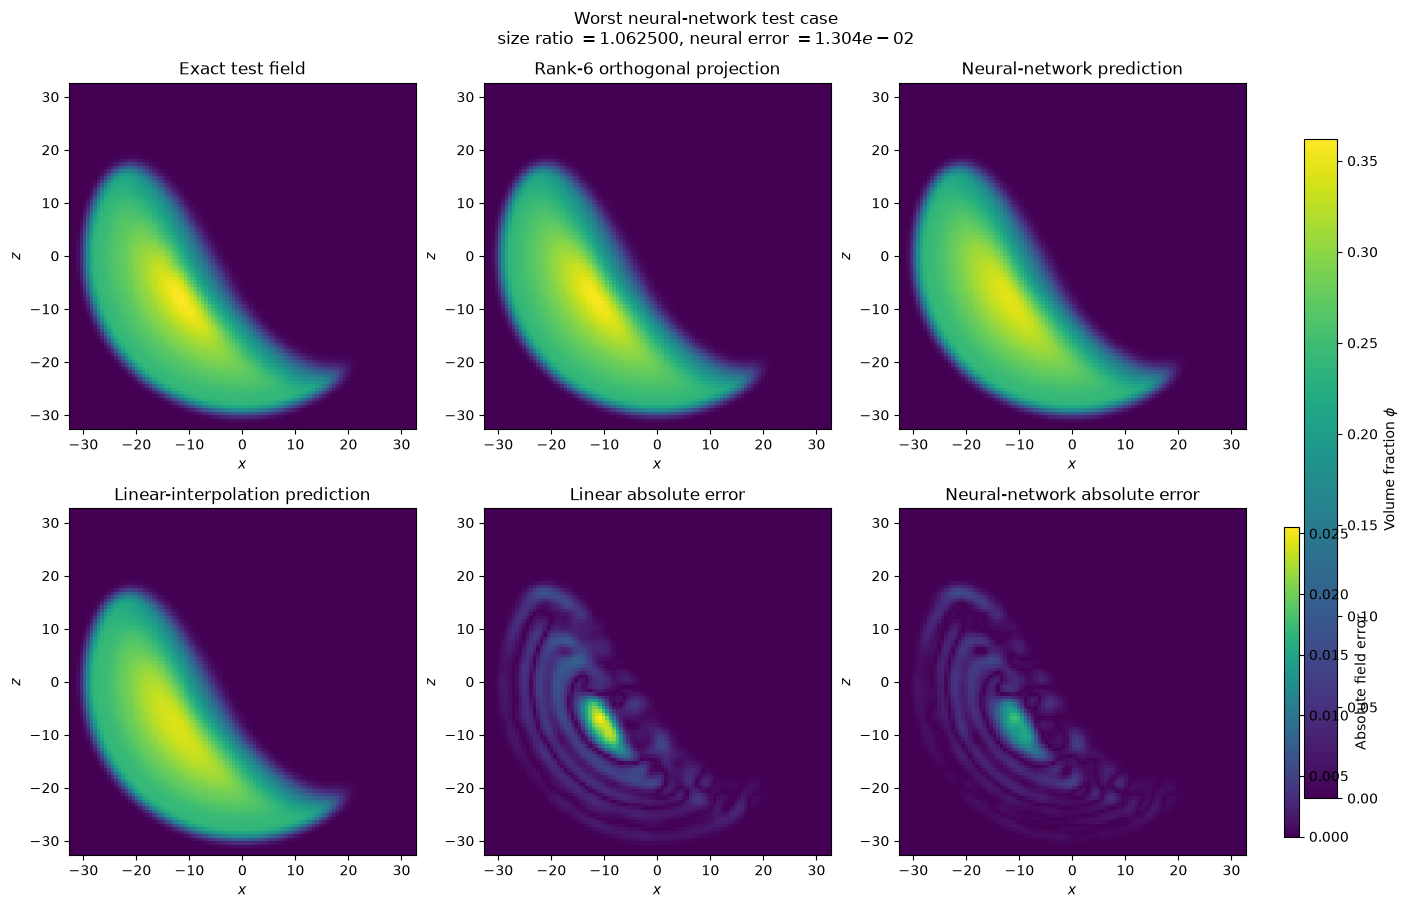

Worst neural-network parameter: 1.062500
Projection error: 6.478828e-03
Linear error: 1.906144e-02
Neural-network error: 1.304164e-02

Saved figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_worst_neural_surrogate_prediction.pdf


In [13]:
worst_neural_index = int(
    np.argmax(
        neural_test_errors
    )
)

worst_neural_parameter = float(
    test_parameters[
        worst_neural_index
    ]
)

exact_worst_field = test_snapshot_matrix[
    :,
    worst_neural_index,
].reshape(
    len(z_grid),
    len(x_grid),
    order="C",
)

projected_worst_field = projected_test_snapshots[
    :,
    worst_neural_index,
].reshape(
    len(z_grid),
    len(x_grid),
    order="C",
)

linear_worst_field = linear_predicted_snapshots[
    :,
    worst_neural_index,
].reshape(
    len(z_grid),
    len(x_grid),
    order="C",
)

neural_worst_field = neural_test_snapshots[
    :,
    worst_neural_index,
].reshape(
    len(z_grid),
    len(x_grid),
    order="C",
)

linear_absolute_error_field = np.abs(
    exact_worst_field
    - linear_worst_field
)

neural_absolute_error_field = np.abs(
    exact_worst_field
    - neural_worst_field
)

physical_maximum = max(
    exact_worst_field.max(),
    projected_worst_field.max(),
    linear_worst_field.max(),
    neural_worst_field.max(),
)

error_maximum = max(
    linear_absolute_error_field.max(),
    neural_absolute_error_field.max(),
)

figure, axes = plt.subplots(
    2,
    3,
    figsize=(14, 9),
    constrained_layout=True,
)

physical_fields = [
    exact_worst_field,
    projected_worst_field,
    neural_worst_field,
]

physical_titles = [
    "Exact test field",
    "Rank-6 orthogonal projection",
    "Neural-network prediction",
]

for axis, field, title in zip(
    axes[0],
    physical_fields,
    physical_titles,
):
    physical_image = axis.imshow(
        field,
        origin="lower",
        extent=(
            x_grid.min(),
            x_grid.max(),
            z_grid.min(),
            z_grid.max(),
        ),
        aspect="equal",
        interpolation="nearest",
        vmin=0.0,
        vmax=physical_maximum,
    )

    axis.set_title(title)
    axis.set_xlabel(r"$x$")
    axis.set_ylabel(r"$z$")

axes[1, 0].imshow(
    linear_worst_field,
    origin="lower",
    extent=(
        x_grid.min(),
        x_grid.max(),
        z_grid.min(),
        z_grid.max(),
    ),
    aspect="equal",
    interpolation="nearest",
    vmin=0.0,
    vmax=physical_maximum,
)

axes[1, 0].set_title(
    "Linear-interpolation prediction"
)

axes[1, 0].set_xlabel(r"$x$")
axes[1, 0].set_ylabel(r"$z$")

linear_error_image = axes[1, 1].imshow(
    linear_absolute_error_field,
    origin="lower",
    extent=(
        x_grid.min(),
        x_grid.max(),
        z_grid.min(),
        z_grid.max(),
    ),
    aspect="equal",
    interpolation="nearest",
    vmin=0.0,
    vmax=error_maximum,
)

axes[1, 1].set_title(
    "Linear absolute error"
)

axes[1, 1].set_xlabel(r"$x$")
axes[1, 1].set_ylabel(r"$z$")

axes[1, 2].imshow(
    neural_absolute_error_field,
    origin="lower",
    extent=(
        x_grid.min(),
        x_grid.max(),
        z_grid.min(),
        z_grid.max(),
    ),
    aspect="equal",
    interpolation="nearest",
    vmin=0.0,
    vmax=error_maximum,
)

axes[1, 2].set_title(
    "Neural-network absolute error"
)

axes[1, 2].set_xlabel(r"$x$")
axes[1, 2].set_ylabel(r"$z$")

physical_colour_bar = figure.colorbar(
    physical_image,
    ax=[
        axes[0, 0],
        axes[0, 1],
        axes[0, 2],
        axes[1, 0],
    ],
    shrink=0.82,
)

physical_colour_bar.set_label(
    r"Volume fraction $\phi$"
)

error_colour_bar = figure.colorbar(
    linear_error_image,
    ax=[
        axes[1, 1],
        axes[1, 2],
    ],
    shrink=0.82,
)

error_colour_bar.set_label(
    "Absolute field error"
)

figure.suptitle(
    "Worst neural-network test case\n"
    rf"size ratio $={worst_neural_parameter:.6f}$, "
    rf"neural error $="
    rf"{neural_test_errors[worst_neural_index]:.3e}$"
)

worst_prediction_figure_path = (
    FIGURE_DIR
    / "cg_phi_worst_neural_surrogate_prediction.pdf"
)

figure.savefig(
    worst_prediction_figure_path,
    bbox_inches="tight",
)

plt.show()

print(
    "Worst neural-network parameter:",
    f"{worst_neural_parameter:.6f}",
)

print(
    "Projection error:",
    f"{projection_relative_errors[worst_neural_index]:.6e}",
)

print(
    "Linear error:",
    f"{linear_relative_errors[worst_neural_index]:.6e}",
)

print(
    "Neural-network error:",
    f"{neural_test_errors[worst_neural_index]:.6e}",
)

print("\nSaved figure:")
print(worst_prediction_figure_path)

In [14]:
x_spacing = float(
    np.mean(
        np.diff(x_grid)
    )
)

z_spacing = float(
    np.mean(
        np.diff(z_grid)
    )
)

grid_cell_area = (
    x_spacing
    * z_spacing
)

neural_diagnostic_records = []

for test_index, parameter in enumerate(
    test_parameters
):
    exact_snapshot = test_snapshot_matrix[
        :,
        test_index,
    ]

    neural_snapshot = neural_test_snapshots[
        :,
        test_index,
    ]

    exact_integrated_volume = (
        exact_snapshot.sum()
        * grid_cell_area
    )

    neural_integrated_volume = (
        neural_snapshot.sum()
        * grid_cell_area
    )

    relative_volume_error = (
        abs(
            neural_integrated_volume
            - exact_integrated_volume
        )
        / abs(
            exact_integrated_volume
        )
    )

    neural_diagnostic_records.append(
        {
            "size_ratio": parameter,
            "relative_field_error": (
                neural_test_errors[
                    test_index
                ]
            ),
            "projection_error": (
                projection_relative_errors[
                    test_index
                ]
            ),
            "exact_integrated_volume": (
                exact_integrated_volume
            ),
            "predicted_integrated_volume": (
                neural_integrated_volume
            ),
            "relative_volume_error": (
                relative_volume_error
            ),
            "predicted_minimum": float(
                neural_snapshot.min()
            ),
            "predicted_maximum": float(
                neural_snapshot.max()
            ),
            "fraction_below_zero": float(
                np.mean(
                    neural_snapshot < 0.0
                )
            ),
            "fraction_below_minus_1e_6": float(
                np.mean(
                    neural_snapshot < -1e-6
                )
            ),
            "fraction_below_minus_1e_5": float(
                np.mean(
                    neural_snapshot < -1e-5
                )
            ),
            "fraction_above_one": float(
                np.mean(
                    neural_snapshot > 1.0
                )
            ),
        }
    )

neural_diagnostics = pd.DataFrame(
    neural_diagnostic_records
)

print("Neural-surrogate physical diagnostics")
print("-------------------------------------")

print(
    "Mean relative field error:",
    f"{neural_diagnostics['relative_field_error'].mean():.6e}",
)

print(
    "Maximum relative field error:",
    f"{neural_diagnostics['relative_field_error'].max():.6e}",
)

print(
    "Mean integrated-volume error:",
    f"{neural_diagnostics['relative_volume_error'].mean():.6e}",
)

print(
    "Maximum integrated-volume error:",
    f"{neural_diagnostics['relative_volume_error'].max():.6e}",
)

print(
    "Minimum predicted value:",
    f"{neural_diagnostics['predicted_minimum'].min():.6e}",
)

print(
    "Maximum predicted value:",
    f"{neural_diagnostics['predicted_maximum'].max():.6e}",
)

print(
    "Largest fraction below -1e-6:",
    f"{neural_diagnostics['fraction_below_minus_1e_6'].max():.6e}",
)

print(
    "Largest fraction below -1e-5:",
    f"{neural_diagnostics['fraction_below_minus_1e_5'].max():.6e}",
)

print(
    "Largest fraction above one:",
    f"{neural_diagnostics['fraction_above_one'].max():.6e}",
)

neural_diagnostics_path = (
    TABLE_DIR
    / "cg_phi_neural_surrogate_diagnostics.csv"
)

neural_diagnostics.to_csv(
    neural_diagnostics_path,
    index=False,
)

print("\nSaved diagnostics table:")
print(neural_diagnostics_path)

display(
    neural_diagnostics
)

Neural-surrogate physical diagnostics
-------------------------------------
Mean relative field error: 8.392985e-03
Maximum relative field error: 1.304164e-02
Mean integrated-volume error: 2.877259e-05
Maximum integrated-volume error: 8.641804e-05
Minimum predicted value: -1.201077e-06
Maximum predicted value: 5.374356e-01
Largest fraction below -1e-6: 3.000000e-04
Largest fraction below -1e-5: 0.000000e+00
Largest fraction above one: 0.000000e+00

Saved diagnostics table:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_neural_surrogate_diagnostics.csv


,size_ratio,relative_field_error,projection_error,exact_integrated_volume,predicted_integrated_volume,relative_volume_error,predicted_minimum,predicted_maximum,fraction_below_zero,fraction_below_minus_1e_6,fraction_below_minus_1e_5,fraction_above_one
0,1.0625,0.013042,0.006479,282.746837,282.771272,8.641804e-05,-2.892754e-07,0.346957,0.0496,0.0000,0.0,0.0
1,1.1250,0.012361,0.007215,282.756124,282.765908,3.460226e-05,-9.794555e-07,0.404191,0.0311,0.0000,0.0,0.0
2,1.2500,0.008708,0.005612,282.756398,282.760359,1.400907e-05,-1.201077e-06,0.479253,0.0269,0.0003,0.0,0.0
3,1.3125,0.008648,0.004812,282.763596,282.758546,1.786017e-05,-3.145947e-07,0.498954,0.0224,0.0000,0.0,0.0
4,1.3750,0.007468,0.003677,282.743538,282.757006,4.763178e-05,-1.157399e-07,0.510343,0.0226,0.0000,0.0,0.0
5,1.5000,0.010770,0.004636,282.768780,282.755428,4.721879e-05,-1.530466e-07,0.524725,0.0221,0.0000,0.0,0.0
6,1.5625,0.005838,0.004612,282.751839,282.755040,1.132007e-05,-3.252888e-07,0.529552,0.0229,0.0000,0.0,0.0
7,1.6250,0.007464,0.004527,282.752691,282.754590,6.713802e-06,-3.328549e-07,0.533031,0.0200,0.0000,0.0,0.0
8,1.7500,0.004777,0.004430,282.759771,282.753682,2.153537e-05,-1.539111e-07,0.536606,0.0070,0.0000,0.0,0.0
9,1.8750,0.004855,0.004349,282.753462,282.753344,4.165186e-07,-3.344152e-08,0.537436,0.0092,0.0000,0.0,0.0


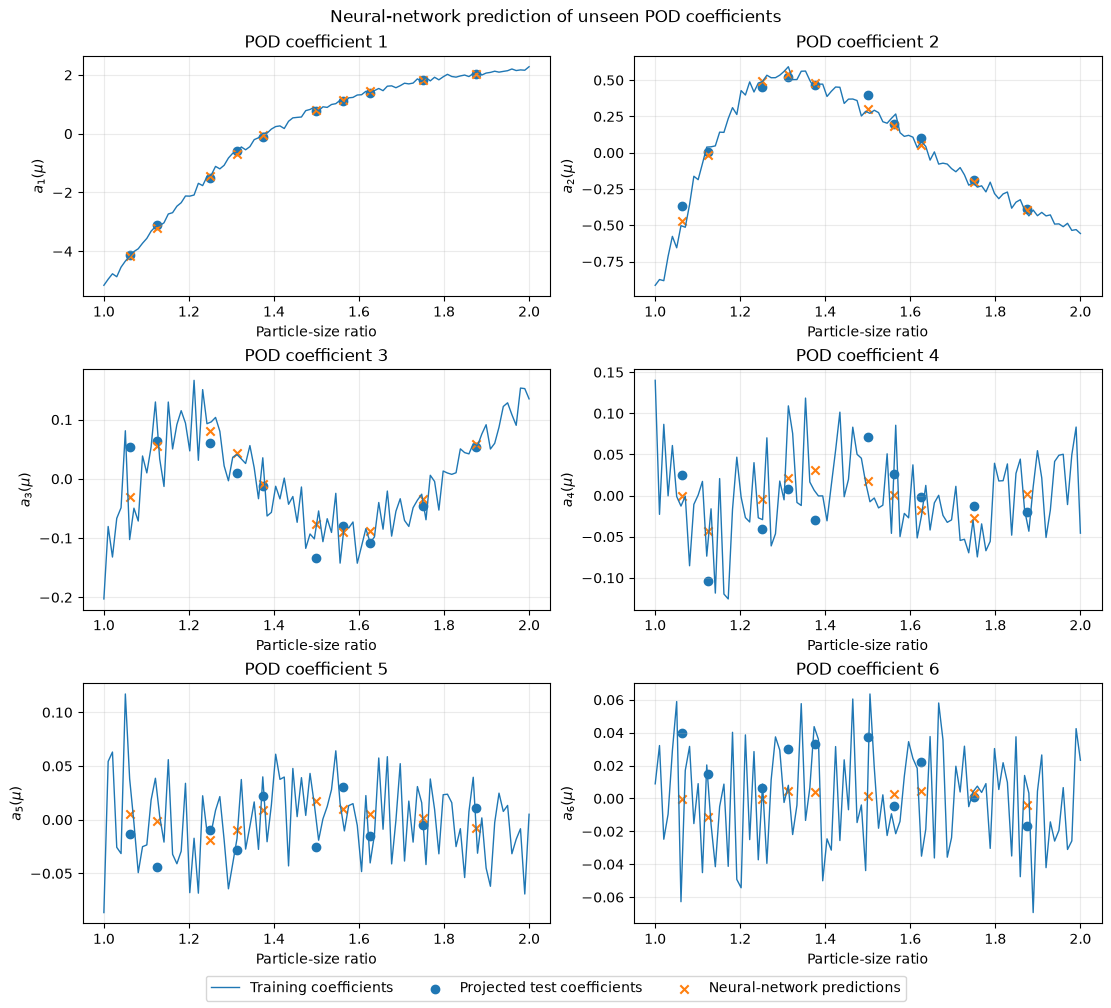

Saved coefficient comparison:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_neural_predicted_coefficients.pdf


In [15]:
figure, axes = plt.subplots(
    3,
    2,
    figsize=(11, 10),
    constrained_layout=True,
)

axes = axes.ravel()

for mode_index, axis in enumerate(axes):
    axis.plot(
        train_parameters,
        train_coefficients[mode_index, :],
        linewidth=1.0,
        label="Training coefficients",
    )

    axis.scatter(
        test_parameters,
        projected_test_coefficients[
            mode_index,
            :,
        ],
        marker="o",
        label="Projected test coefficients",
    )

    axis.scatter(
        test_parameters,
        neural_test_coefficients[
            mode_index,
            :,
        ],
        marker="x",
        label="Neural-network predictions",
    )

    axis.set_xlabel(
        "Particle-size ratio"
    )

    axis.set_ylabel(
        rf"$a_{mode_index + 1}(\mu)$"
    )

    axis.set_title(
        f"POD coefficient {mode_index + 1}"
    )

    axis.grid(
        alpha=0.25
    )

handles, labels = axes[0].get_legend_handles_labels()

figure.legend(
    handles,
    labels,
    loc="outside lower center",
    ncol=3,
)

figure.suptitle(
    "Neural-network prediction of unseen POD coefficients"
)

coefficient_comparison_path = (
    FIGURE_DIR
    / "cg_phi_neural_predicted_coefficients.pdf"
)

figure.savefig(
    coefficient_comparison_path,
    bbox_inches="tight",
)

plt.show()

print("Saved coefficient comparison:")
print(coefficient_comparison_path)

In [16]:
import joblib


final_input_scaler = StandardScaler()
final_output_scaler = StandardScaler()

final_training_inputs = (
    final_input_scaler.fit_transform(
        train_parameters.reshape(-1, 1)
    )
)

final_training_outputs = (
    final_output_scaler.fit_transform(
        train_coefficients.T
    )
)

final_neural_model = MLPRegressor(
    hidden_layer_sizes=best_neural_candidate[
        "hidden_layer_sizes"
    ],
    activation="tanh",
    solver="lbfgs",
    alpha=best_neural_candidate["alpha"],
    max_iter=5000,
    random_state=42,
)

final_neural_model.fit(
    final_training_inputs,
    final_training_outputs,
)


def predict_volume_fraction_field(
    size_ratio: float,
) -> np.ndarray:
    """
    Predict a complete volume-fraction field from particle-size ratio.

    The current ROM is intended for interpolation over the training
    interval 1.0 <= size_ratio <= 2.0.
    """
    size_ratio = float(size_ratio)

    training_minimum = float(
        train_parameters.min()
    )

    training_maximum = float(
        train_parameters.max()
    )

    if not (
        training_minimum
        <= size_ratio
        <= training_maximum
    ):
        raise ValueError(
            "Requested size ratio lies outside the training interval "
            f"[{training_minimum}, {training_maximum}]."
        )

    scaled_input = (
        final_input_scaler.transform(
            np.array([[size_ratio]])
        )
    )

    scaled_coefficients = (
        final_neural_model.predict(
            scaled_input
        )
    )

    predicted_coefficients = (
        final_output_scaler.inverse_transform(
            scaled_coefficients
        ).reshape(
            selected_rank,
            1,
        )
    )

    predicted_snapshot = (
        mean_snapshot_vector
        + pod_basis
        @ predicted_coefficients
    )

    return predicted_snapshot.reshape(
        len(z_grid),
        len(x_grid),
        order="C",
    )


rom_package = {
    "model": final_neural_model,
    "input_scaler": final_input_scaler,
    "output_scaler": final_output_scaler,
    "mean_snapshot_vector": mean_snapshot_vector,
    "pod_basis": pod_basis,
    "x_grid": x_grid,
    "z_grid": z_grid,
    "selected_rank": selected_rank,
    "training_parameter_minimum": float(
        train_parameters.min()
    ),
    "training_parameter_maximum": float(
        train_parameters.max()
    ),
    "hidden_layer_sizes": best_neural_candidate[
        "hidden_layer_sizes"
    ],
    "regularisation_alpha": best_neural_candidate[
        "alpha"
    ],
}

rom_package_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "cg_phi_rank6_neural_rom.joblib"
)

joblib.dump(
    rom_package,
    rom_package_path,
)

print("Saved deployable ROM:")
print(rom_package_path)

print(
    "Saved file size:",
    f"{rom_package_path.stat().st_size / 1024**2:.2f} MB",
)

# Verify that the saved model can be reopened.
loaded_rom_package = joblib.load(
    rom_package_path
)

assert loaded_rom_package[
    "selected_rank"
] == selected_rank

assert loaded_rom_package[
    "pod_basis"
].shape == (
    10000,
    selected_rank,
)

print("\nSaved ROM verification passed.")

Saved deployable ROM:
/Users/rallen/Documents/msc-rom-particle-systems/data/processed/cg_phi_rank6_neural_rom.joblib
Saved file size: 0.54 MB

Saved ROM verification passed.


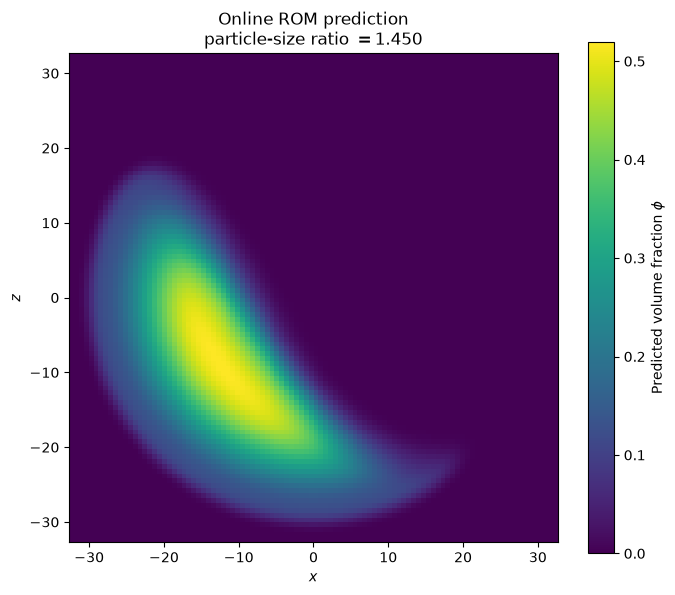

Demonstration parameter: 1.45
Predicted minimum: -1.247977e-07
Predicted maximum: 5.196705e-01
Predicted integrated volume: 282.755843

Saved online prediction figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_online_prediction_mu_1_45.pdf


In [17]:
demonstration_parameter = 1.45

demonstration_field = (
    predict_volume_fraction_field(
        demonstration_parameter
    )
)

x_spacing = float(
    np.mean(
        np.diff(x_grid)
    )
)

z_spacing = float(
    np.mean(
        np.diff(z_grid)
    )
)

predicted_integrated_volume = (
    demonstration_field.sum()
    * x_spacing
    * z_spacing
)

figure, axis = plt.subplots(
    figsize=(7, 6)
)

image = axis.imshow(
    demonstration_field,
    origin="lower",
    extent=(
        x_grid.min(),
        x_grid.max(),
        z_grid.min(),
        z_grid.max(),
    ),
    aspect="equal",
    interpolation="nearest",
    vmin=0.0,
)

colour_bar = figure.colorbar(
    image,
    ax=axis,
)

colour_bar.set_label(
    r"Predicted volume fraction $\phi$"
)

axis.set_xlabel(r"$x$")
axis.set_ylabel(r"$z$")

axis.set_title(
    "Online ROM prediction\n"
    rf"particle-size ratio $={demonstration_parameter:.3f}$"
)

figure.tight_layout()

demonstration_figure_path = (
    FIGURE_DIR
    / "cg_phi_online_prediction_mu_1_45.pdf"
)

figure.savefig(
    demonstration_figure_path,
    bbox_inches="tight",
)

plt.show()

print(
    "Demonstration parameter:",
    demonstration_parameter,
)

print(
    "Predicted minimum:",
    f"{demonstration_field.min():.6e}",
)

print(
    "Predicted maximum:",
    f"{demonstration_field.max():.6e}",
)

print(
    "Predicted integrated volume:",
    f"{predicted_integrated_volume:.6f}",
)

print("\nSaved online prediction figure:")
print(demonstration_figure_path)

In [18]:
import time


def predict_from_saved_rom(
    package: dict,
    size_ratio: float,
) -> np.ndarray:
    """Generate a field using only the saved ROM package."""
    size_ratio = float(size_ratio)

    minimum_parameter = package[
        "training_parameter_minimum"
    ]

    maximum_parameter = package[
        "training_parameter_maximum"
    ]

    if not (
        minimum_parameter
        <= size_ratio
        <= maximum_parameter
    ):
        raise ValueError(
            "The requested parameter lies outside the "
            f"training interval [{minimum_parameter}, "
            f"{maximum_parameter}]."
        )

    scaled_input = package[
        "input_scaler"
    ].transform(
        np.array(
            [[size_ratio]],
            dtype=float,
        )
    )

    scaled_coefficients = package[
        "model"
    ].predict(
        scaled_input
    )

    coefficients = package[
        "output_scaler"
    ].inverse_transform(
        scaled_coefficients
    ).reshape(
        package["selected_rank"],
        1,
    )

    predicted_snapshot = (
        package["mean_snapshot_vector"]
        + package["pod_basis"]
        @ coefficients
    )

    return predicted_snapshot.reshape(
        package["z_grid"].size,
        package["x_grid"].size,
        order="C",
    )


reloaded_demonstration_field = (
    predict_from_saved_rom(
        loaded_rom_package,
        demonstration_parameter,
    )
)

maximum_reload_difference = np.max(
    np.abs(
        reloaded_demonstration_field
        - demonstration_field
    )
)

print(
    "Maximum difference after reloading:",
    f"{maximum_reload_difference:.6e}",
)

assert np.allclose(
    reloaded_demonstration_field,
    demonstration_field,
    rtol=1e-12,
    atol=1e-12,
)

print(
    "Reloaded ROM reproduces the original prediction."
)


# Benchmark parameters cover the interpolation interval.
benchmark_parameters = np.linspace(
    train_parameters.min(),
    train_parameters.max(),
    100,
)

# Warm-up calls are excluded from the timing measurements.
for parameter in benchmark_parameters[:10]:
    predict_from_saved_rom(
        loaded_rom_package,
        parameter,
    )

prediction_times = []

for _ in range(20):
    for parameter in benchmark_parameters:
        start_time = time.perf_counter()

        predict_from_saved_rom(
            loaded_rom_package,
            parameter,
        )

        end_time = time.perf_counter()

        prediction_times.append(
            end_time - start_time
        )

prediction_times = np.asarray(
    prediction_times
)

prediction_times_ms = (
    prediction_times * 1000.0
)

mean_prediction_time_ms = float(
    prediction_times_ms.mean()
)

median_prediction_time_ms = float(
    np.median(
        prediction_times_ms
    )
)

percentile_95_time_ms = float(
    np.percentile(
        prediction_times_ms,
        95,
    )
)

print("\nOnline ROM timing")
print("-----------------")

print(
    "Number of timed predictions:",
    prediction_times_ms.size,
)

print(
    "Mean prediction time:",
    f"{mean_prediction_time_ms:.6f} ms",
)

print(
    "Median prediction time:",
    f"{median_prediction_time_ms:.6f} ms",
)

print(
    "95th-percentile prediction time:",
    f"{percentile_95_time_ms:.6f} ms",
)

Maximum difference after reloading: 0.000000e+00
Reloaded ROM reproduces the original prediction.

Online ROM timing
-----------------
Number of timed predictions: 2000
Mean prediction time: 0.471844 ms
Median prediction time: 0.415437 ms
95th-percentile prediction time: 0.691855 ms


Final ROM summary:


,pod_rank,captured_fluctuation_energy,projection_mean_error,projection_maximum_error,linear_cv_mean_error,linear_test_mean_error,linear_test_maximum_error,neural_cv_mean_error,neural_test_mean_error,neural_test_maximum_error,neural_mean_volume_error,neural_maximum_volume_error,minimum_neural_prediction,maximum_neural_prediction,mean_online_time_ms,median_online_time_ms,percentile_95_online_time_ms
0,6,0.999029,0.005035,0.007215,0.010391,0.009821,0.019061,0.009047,0.008393,0.013042,0.000029,0.000086,-0.000001,0.537436,0.471844,0.415437,0.691855



Saved summary:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_rank6_neural_rom_summary.csv


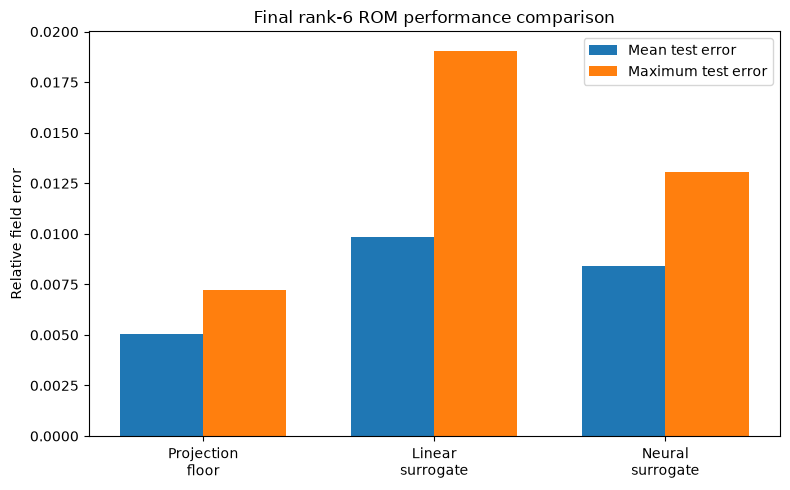


Saved error-summary figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_final_rom_error_summary.pdf


In [19]:
final_rom_summary = pd.DataFrame(
    [
        {
            "pod_rank": selected_rank,
            "captured_fluctuation_energy": (
                captured_energy
            ),
            "projection_mean_error": (
                projection_relative_errors.mean()
            ),
            "projection_maximum_error": (
                projection_relative_errors.max()
            ),
            "linear_cv_mean_error": float(
                linear_cv_row[
                    "mean_field_error"
                ]
            ),
            "linear_test_mean_error": (
                linear_relative_errors.mean()
            ),
            "linear_test_maximum_error": (
                linear_relative_errors.max()
            ),
            "neural_cv_mean_error": float(
                neural_cv_row[
                    "mean_field_error"
                ]
            ),
            "neural_test_mean_error": (
                neural_test_errors.mean()
            ),
            "neural_test_maximum_error": (
                neural_test_errors.max()
            ),
            "neural_mean_volume_error": (
                neural_diagnostics[
                    "relative_volume_error"
                ].mean()
            ),
            "neural_maximum_volume_error": (
                neural_diagnostics[
                    "relative_volume_error"
                ].max()
            ),
            "minimum_neural_prediction": (
                neural_diagnostics[
                    "predicted_minimum"
                ].min()
            ),
            "maximum_neural_prediction": (
                neural_diagnostics[
                    "predicted_maximum"
                ].max()
            ),
            "mean_online_time_ms": (
                mean_prediction_time_ms
            ),
            "median_online_time_ms": (
                median_prediction_time_ms
            ),
            "percentile_95_online_time_ms": (
                percentile_95_time_ms
            ),
        }
    ]
)

final_summary_path = (
    TABLE_DIR
    / "cg_phi_rank6_neural_rom_summary.csv"
)

final_rom_summary.to_csv(
    final_summary_path,
    index=False,
)

print("Final ROM summary:")
display(final_rom_summary)

print("\nSaved summary:")
print(final_summary_path)


model_labels = [
    "Projection\nfloor",
    "Linear\nsurrogate",
    "Neural\nsurrogate",
]

mean_model_errors = np.array(
    [
        projection_relative_errors.mean(),
        linear_relative_errors.mean(),
        neural_test_errors.mean(),
    ]
)

maximum_model_errors = np.array(
    [
        projection_relative_errors.max(),
        linear_relative_errors.max(),
        neural_test_errors.max(),
    ]
)

bar_positions = np.arange(
    len(model_labels)
)

bar_width = 0.36

figure, axis = plt.subplots(
    figsize=(8, 5)
)

axis.bar(
    bar_positions - bar_width / 2,
    mean_model_errors,
    width=bar_width,
    label="Mean test error",
)

axis.bar(
    bar_positions + bar_width / 2,
    maximum_model_errors,
    width=bar_width,
    label="Maximum test error",
)

axis.set_xticks(
    bar_positions
)

axis.set_xticklabels(
    model_labels
)

axis.set_ylabel(
    "Relative field error"
)

axis.set_title(
    "Final rank-6 ROM performance comparison"
)

axis.legend()
figure.tight_layout()

final_error_figure_path = (
    FIGURE_DIR
    / "cg_phi_final_rom_error_summary.pdf"
)

figure.savefig(
    final_error_figure_path,
    bbox_inches="tight",
)

plt.show()

print("\nSaved error-summary figure:")
print(final_error_figure_path)

## Conclusions

A non-intrusive reduced-order model has been constructed for the
coarse-grained rotating-drum volume-fraction field.

The mean-centred representation is

$$
\phi(\mu)
\approx
\overline{\phi}
+
\sum_{i=1}^{6}
a_i(\mu)\psi_i,
$$

where the mean field and six POD modes were calculated using only the 100
training simulations. The six retained modes capture approximately 99.903%
of the fluctuation energy.

The rank-six basis gives a mean projection error of approximately 0.503% and
a maximum projection error of approximately 0.722% on the ten unseen test
fields. These values represent the approximation limit of the fixed rank-six
POD space before surrogate-prediction error is introduced.

Training-only cross-validation was used to compare linear interpolation,
shape-preserving interpolation, cubic interpolation and several regularised
neural-network models. Linear interpolation was the strongest interpolation
baseline, producing a mean unseen test error of approximately 0.982%.

The selected neural surrogate has one hidden layer containing 16 neurons,
hyperbolic-tangent activation and regularisation parameter 0.1. It achieved:

- training-only cross-validation error of approximately 0.905%;
- mean unseen test error of approximately 0.839%;
- maximum unseen test error of approximately 1.304%;
- a 14.54% reduction in mean error relative to linear interpolation;
- a 31.58% reduction in maximum error relative to linear interpolation.

The predictions preserve integrated particle volume accurately. The mean
relative integrated-volume error is approximately 0.0029%, while the maximum
is below 0.009%. No predictions exceed a volume fraction of one, and the
small negative values have negligible magnitude.

The saved online ROM accepts a particle-size ratio between 1.0 and 2.0,
predicts six reduced coefficients and reconstructs the complete 10,000-point
field without accessing a target simulation. On the present computer, the
median online evaluation time is approximately 0.42 milliseconds and the
95th-percentile time is approximately 0.69 milliseconds. These values
describe ROM inference only and are not yet presented as a formal speed-up
relative to the original particle simulation.

The present model provides a validated end-to-end baseline. The next
methodological question is whether increasing the POD rank improves overall
prediction accuracy, or instead introduces higher-order coefficients that are
too noisy for the surrogate to predict reliably. Extrapolation outside the
training interval from 1.0 to 2.0 is not supported.